# Mean field

In [1]:
using Plots
using ProgressMeter

In [2]:
function describe_mean_field(J1,J2,J3)
    I1 = -2*(J1+J2+4*J3)
    I2 = -1/8*(J1+4*J2+16*J3)
    I3 = 1/24*(J1-4*J2+16*J3)
    println("I1 = ", I1,"\nI2 = ", I2)
    println("spatial anisotropy ratio : ", I3/I2)
    x0 = sqrt(I2/I1)
    println("sqrt(I2/I1) length scale = ", x0)
    println("H_MF = ",I2/I1^2, " H_Micro")
    return x0
end
J1 = 1.0; J2 = -0.5; J3 = 1/16*(-J1+4*J2); K = 0.0
describe_mean_field(J1,J2,J3)

I1 = 0.5
I2 = 0.5
spatial anisotropy ratio : 0.0
sqrt(I2/I1) length scale = 1.0
H_MF = 2.0 H_Micro


1.0

## The Hamiltonian

In [3]:
function H_vect(n, J1, J2, J3, K, B, boundary)
    E = 0.0
    nx, ny = size(n, 2), size(n, 3)
    for i in 1:nx
        for j in 1:ny
            n_a = n[:, i, j]
            # account for the anisotropy
            E -= K * n_a[3]^2
            # add external field
            E -= B[i, j] * n_a[3]
            for (k, l) in [(i+1, j), (i, j+1)]
                if boundary == "periodic"
                    k = mod1(k, nx)
                    l = mod1(l, ny)
                else # free BCs
                    if k > nx || l > ny || k < 1 || l < 1
                        continue
                    end
                end
                n_b = n[:, k, l]
                E -= J1 * (n_a[1]*n_b[1] + n_a[2]*n_b[2] + n_a[3]*n_b[3])
            end
            for (k, l) in [(i+1, j+1), (i+1, j-1)]
                if boundary == "periodic"
                    k = mod1(k, nx)
                    l = mod1(l, ny)
                else # free BCs
                    if k > nx || l > ny || k < 1 || l < 1
                        continue
                    end
                end
                n_b = n[:, k, l]
                E -= J2 * (n_a[1]*n_b[1] + n_a[2]*n_b[2] + n_a[3]*n_b[3])
            end
            for (k, l) in [(i+2, j), (i, j+2)]
                if boundary == "periodic"
                    k = mod1(k, nx)
                    l = mod1(l, ny)
                else # free BCs
                    if k > nx || l > ny || k < 1 || l < 1
                        continue
                    end
                end
                n_b = n[:, k, l]
                E -= J3 * (n_a[1]*n_b[1] + n_a[2]*n_b[2] + n_a[3]*n_b[3])
            end
        end
    end

    # subtract the energy of the FM state
    if boundary == "periodic"
        E += sum(B) + nx * ny * (K + 2*J1 + 2*J2 + 2*J3)
    elseif boundary == "free"
        E += sum(B) + nx * ny * K + J1 * (2*nx*ny - (nx + ny)) + J2 * (2*nx*ny - 2*(nx + ny) + 2) + J3 * (2*nx*ny - 2*(nx + ny))
    end
    return E
end

H_vect (generic function with 1 method)

In [4]:
function ferromagnetic(nx,ny)
    n = zeros(3,nx,ny)
    n[3,:,:] .= 1.0
    return n
end

function normalize!(n)
    for i=1:n.size[2]
        for j=1:n.size[3]
            n[:,i,j] *= 1/sqrt(sum(n[:,i,j].^2))
        end
    end
    return n
end

function check_norm(n)
    norm = zeros(n.size[2],n.size[3])
    for i=1:n.size[2]
        for j=1:n.size[3]
            norm[i,j] = sqrt(sum(n[:,i,j].^2))
        end
    end
    println("Norm varies from ", min.(norm), "to", max.(norm))
end

function random_configuration(nx,ny)
    n = randn((3,nx,ny))
    normalize!(n)
    return n
end

function rotate_around_z(n, phi)
    n_new = copy(n)
    n_new[1,:,:] = cos(phi) * n[1,:,:] - sin(phi) * n[2,:,:]
    n_new[2,:,:] = sin(phi) * n[1,:,:] + cos(phi) * n[2,:,:]
    return n_new
end

function uniform_B(nx,ny,B_val)
    return B_val*ones(nx,ny)
end

let
    nx = 10; ny = 7
    J1 = 1.12; J2 = -0.521; J3 = 1/16*(-J1+4*J2)+0.23; K = 0.007
    B = uniform_B(nx,ny,0.12)
    boundary = "periodic"
    E_FM = H_vect(ferromagnetic(nx,ny), J1, J2, J3, K, B, boundary)
    if abs(E_FM) < 1e-10
        println("correct FM energy ------> OK")
    end
end

correct FM energy ------> OK


In [14]:
let
    nx = 5; ny = 6
    J1 = 1.12; J2 = -0.521; J3 = 1/16*(-J1+4*J2)+0.23; K = 0.007
    B = uniform_B(nx,ny,0.12)
    boundary = "free"
    err = 0.0
    for case=1:30
        n = random_configuration(nx,ny)
        H = H_vect(n, J1, J2, J3, K, B, boundary)
        n_new = rotate_around_z(n,2pi*rand())
        H_new = H_vect(n_new, J1, J2, J3, K, B, boundary)
        diff = abs(H-H_new)
        if (diff>err) err = diff end
    end
    println("err = ", err)
    if err<1e-10
        println("S_z invariance ------> test passed")
    end
end

err = 7.105427357601002e-15
S_z invariance ------> test passed


Progress: 100%|█████████████████████████████████████████| Time: 0:00:05


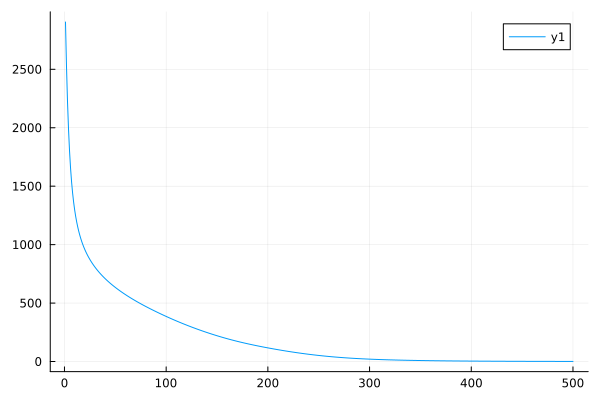

([0.002261764324735258 -0.0020230534625940736 … -0.010809569192539127 -0.013524630039679152; 0.032272216293049515 0.030689927767418117 … 0.08626630511584173 0.08531022609126318; 0.9994766340459234 0.999526933028559 … 0.9962142791867429 0.9962637465044246;;; 0.001552982048115004 -0.004097711405290353 … -0.011054300709614405 -0.01493928547408331; 0.04003508634196988 0.041114240665894045 … 0.08180539401234427 0.08118552614132125; 0.9991971542429429 0.9991461143929908 … 0.9965877111270938 0.9965877976849581;;; -0.0014282376238555303 -0.008125862714370807 … -0.012202028648891102 -0.01676502513854125; 0.05051372182102773 0.05513166327574733 … 0.07322503472194926 0.07384251504181558; 0.9987225202517708 0.998446252494693 … 0.9972413330679043 0.9971296164954582;;; … ;;; -0.01459491970648518 -0.013921512175091303 … 0.11809663431218198 0.1162434635772055; -0.004187845730400384 -0.0012330279165953648 … -0.003237416273510265 0.004129768994215405; 0.9998847383333874 0.9999023437996556 … 0.9929979550

In [13]:
function descent_gradient!(g::Array{Float64,3}, n::Array{Float64,3}, nx::Int, ny::Int, J1::Float64, J2::Float64, 
    J3::Float64, K::Float64, B::Array{Float64,2}, boundary::String)
    g .= 0.0 # the gradient
    for i in 1:nx
        for j in 1:ny
            # external field
            g[3,i,j] += B[i,j]
            # anisotropy
            g[:,i,j] .+= 2*K*n[:,i,j]

            for (k,l) in [(i+1,j),(i,j+1)]
                if boundary == "periodic"
                    k = mod1(k, nx)
                    l = mod1(l, ny)
                else # free BCs
                    if k > nx || l > ny || k < 1 || l < 1
                        continue
                    end
                end
                g[:,i,j] .+= J1 * n[:,k,l]
                g[:,k,l] .+= J1 * n[:,i,j]
            end

            for (k,l) in [(i+1,j+1),(i+1,j-1)]
                if boundary == "periodic"
                    k = mod1(k, nx)
                    l = mod1(l, ny)
                else # free BCs
                    if k > nx || l > ny || k < 1 || l < 1
                        continue
                    end
                end
                g[:,i,j] .+= J2 * n[:,k,l]
                g[:,k,l] .+= J2 * n[:,i,j]
            end

            for (k,l) in [(i+2,j),(i,j+2)]
                if boundary == "periodic"
                    k = mod1(k, nx)
                    l = mod1(l, ny)
                else # free BCs
                    if k > nx || l > ny || k < 1 || l < 1
                        continue
                    end
                end
                g[:,i,j] .+= J3 * n[:,k,l]
                g[:,k,l] .+= J3 * n[:,i,j]
            end
        end
    end

    for i in 1:nx
        for j in 1:ny
            gn = n[1,i,j]*g[1,i,j] + n[2,i,j]*g[2,i,j] + n[3,i,j]*g[3,i,j]
            g[:,i,j] .-= gn * n[:,i,j]
        end
    end
end

function relax(n_init::Array{Float64,3}, nx::Int, ny::Int, J1::Float64, J2::Float64, 
    J3::Float64, K::Float64, B::Array{Float64,2}, dt::Float64, N_steps::Int, boundary::String)
    """
    Gradient descent on H
    """
    g = zeros(size(n_init))
    n = copy(n_init)
    k1 = similar(n_init)

    H_vals = zeros(N_steps)

    @showprogress for i in 1:N_steps
        descent_gradient!(k1,n, nx, ny, J1, J2, J3, K, B, boundary)
        
        # Euler's method
        n .+= k1 .* dt

        # save the energy value
        H_vals[i] = H_vect(n, J1, J2, J3, K, B, boundary)
    end

    P = plot(H_vals)
    display(P)
    return n, H_vals
end

nx = 50; ny = 50
J1 = 1.12; J2 = -0.521; J3 = 1/16*(-J1+4*J2)+0.23; K = 0.007
B = uniform_B(nx,ny,0.12)
boundary = "free"
n_init = random_configuration(nx,ny)

dt = 0.05;
N_steps = 500
boundary = "free"
n_final, H_vals = relax(n_init,nx,ny,J1,J2,J3,K,B,dt,N_steps,boundary)

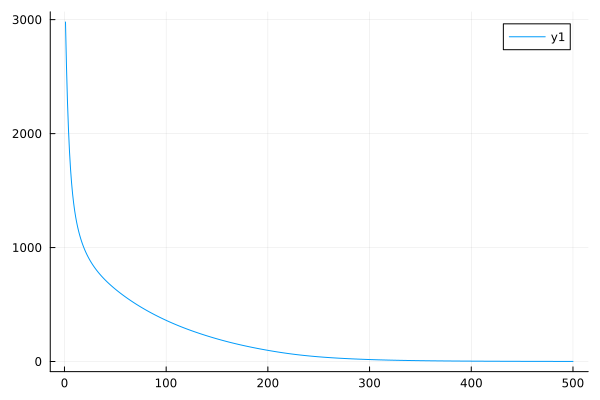

In [12]:
plot(H_vals)